<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Structural breaks: GSADF / BSADF for multiple bubbles
    </h1>
  </div>
</div>

De Prado's **single-window SADF** (AFML ch.17) fixes the test window's
start at the sample origin. When a series contains *more than one* explosive
episode the early sample dilutes the later test, so several bubbles mask one
another and SADF collapses them to about one. **GSADF/BSADF** (Phillips-Shi-Yu
2015) varies *both* window endpoints; the backward BSADF sequence dates each
origination and collapse, recovering and counting every episode.

*Baseline (SADF) -> where it breaks (multiple bubbles) -> GSADF/BSADF -> when to use.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Features: get_sadf_sequence, get_bsadf_sequence, get_gsadf_statistic,
    get_bubble_episodes, psy_minimum_window, simulate_psy_critical_values,
    get_gsadf_statistic, volatility_robust_sadf, pelt_change_points

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


[ Info: Precompiling RiskLabAI [a72881da-fdaa-49c1-8962-99caf4ccfee8] (cache misses: include_dependency fsize change (2), wrong dep version loaded (4), wrong source (4), incompatible header (2), mismatched flags (8))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1. A series with TWO explosive episodes
A random walk with two embedded explosive (mildly super-unit-root) runs.

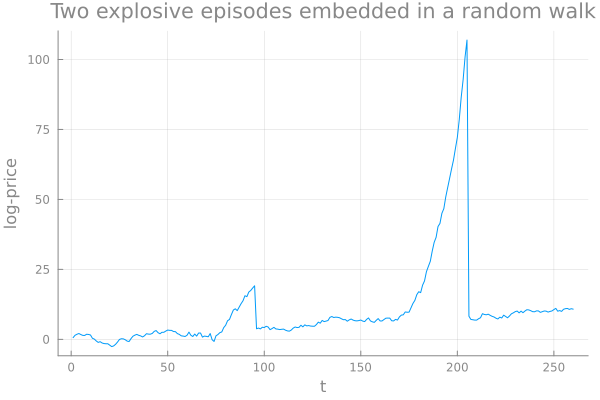

In [2]:
rng = MersenneTwister(7)
T = 260
y = cumsum(randn(rng, T)) .* 0.5
for t in 60:95        # bubble 1
    y[t] = 1.08 * y[t-1] + randn(rng)
end
for t in 170:205      # bubble 2
    y[t] = 1.08 * y[t-1] + randn(rng)
end
plot(y; legend = false, lw = 1, xlabel = "t", ylabel = "log-price",
     title = "Two explosive episodes embedded in a random walk")

## 2. SADF vs BSADF sequences
The forward-expanding SADF is anchored at the origin; the backward-sup BSADF
tests each endpoint on its own sub-sample.

min window = 32   GSADF statistic = 23.108


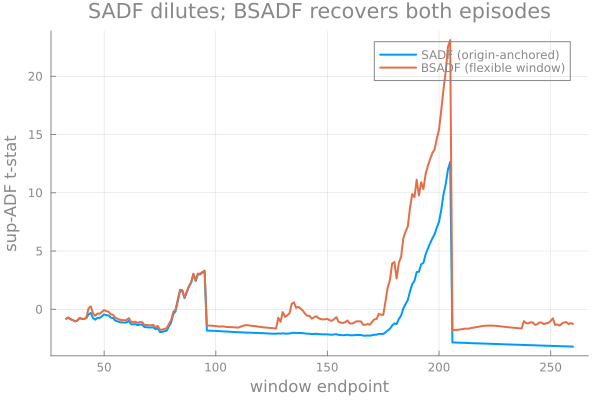

In [3]:
nmin = psy_minimum_window(T)
sadf = get_sadf_sequence(y, nmin, "c", 0)
bsadf = get_bsadf_sequence(y, nmin, "c", 0)
gsadf = get_gsadf_statistic(y, nmin, "c", 0)
println("min window = ", nmin, "   GSADF statistic = ", round(gsadf, digits = 3))

plot(sadf.index, sadf.values; label = "SADF (origin-anchored)", lw = 2,
     xlabel = "window endpoint", ylabel = "sup-ADF t-stat",
     title = "SADF dilutes; BSADF recovers both episodes")
plot!(bsadf.index, bsadf.values; label = "BSADF (flexible window)", lw = 2)

## 3. Date-stamping with simulated finite-sample critical values
Critical values are simulated under the random-walk null (the statistics are
pivotal). Episodes are maximal runs where BSADF exceeds its critical value.

GSADF 95% critical value = 1.9


Detected episodes (origination, collapse): [(88, 96), (178, 206)]


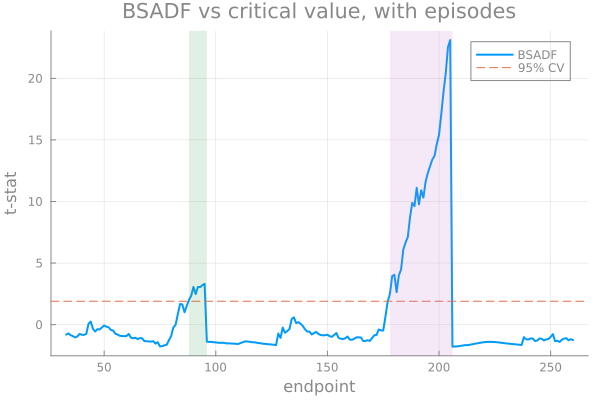

In [4]:
cv = simulate_psy_critical_values(T, nmin; n_simulations = 200, rng = MersenneTwister(0))
episodes = get_bubble_episodes(bsadf.index, bsadf.values, cv.gsadf_global_cv; min_duration = 3)
println("GSADF 95% critical value = ", round(cv.gsadf_global_cv, digits = 3))
println("Detected episodes (origination, collapse): ", episodes)

plot(bsadf.index, bsadf.values; label = "BSADF", lw = 2, xlabel = "endpoint",
     ylabel = "t-stat", title = "BSADF vs critical value, with episodes")
hline!([cv.gsadf_global_cv]; label = "95% CV", ls = :dash)
for (a, b) in episodes
    vspan!([a, b]; alpha = 0.15, label = "")
end
plot!()

## 4. Volatility-robust SADF: holding size under non-stationary volatility

<!-- WAVE29-BREAKS -->
The plain SADF / GSADF sup-ADF statistic assumes **homoskedastic** errors. Under
**non-stationary volatility** it over-rejects and flags **spurious** bubbles.
`volatility_robust_sadf` (Harvey, Leybourne, Sollis and Taylor, 2016) recomputes the
*same* sup-ADF statistics but calibrates the critical values by a **wild bootstrap**
(Rademacher sign-flip of the first-difference residuals), preserving the series' own
volatility pattern while destroying any explosive autocorrelation.

**Regime tag (verbatim, `appraisals/26_verdict.md`):** *prefer it over plain
SADF/GSADF when the series' volatility may be non-stationary: it holds nominal size
where plain SADF over-rejects ~9x, at a modest power cost, and converges to plain SADF
under constant volatility. Pairs with the admitted GSADF/BSADF.*

In [5]:
# WAVE29-BREAKS: empirical SIZE of plain GSADF vs vol-robust under a 4x variance break
function variance_break_size(; n = 200, reps = 40)
    nmin = psy_minimum_window(n)
    homosk_cv = simulate_psy_critical_values(n, nmin; n_simulations = 400,
                                             rng = MersenneTwister(0)).gsadf_global_cv
    plain_rejections = 0
    vr_rejections = 0
    for r in 1:reps
        rng = MersenneTwister(1000 + r)
        shocks = randn(rng, n)
        shocks[(n ÷ 2 + 1):end] .*= 4.0          # 4x variance break, NO explosive root
        y = cumsum(shocks)
        get_gsadf_statistic(y, nmin, "c", 0) > homosk_cv && (plain_rejections += 1)
        volatility_robust_sadf(y; n_bootstrap = 99, random_state = r).reject_gsadf &&
            (vr_rejections += 1)
    end
    return homosk_cv, plain_rejections / reps, vr_rejections / reps
end

homosk_cv, plain_size, vr_size = variance_break_size()
println("4x variance break, NO true bubble (40 realizations; nominal size = 0.05):")
println("  plain GSADF empirical size       = ", round(plain_size, digits = 3),
        "   (over-rejects -> spurious bubbles)")
println("  volatility-robust empirical size = ", round(vr_size, digits = 3),
        "   (holds nominal size)")

4x variance break, NO true bubble (40 realizations; nominal size = 0.05):
  plain GSADF empirical size       = 0.475   (over-rejects -> spurious bubbles)
  volatility-robust empirical size = 0.0   (holds nominal size)


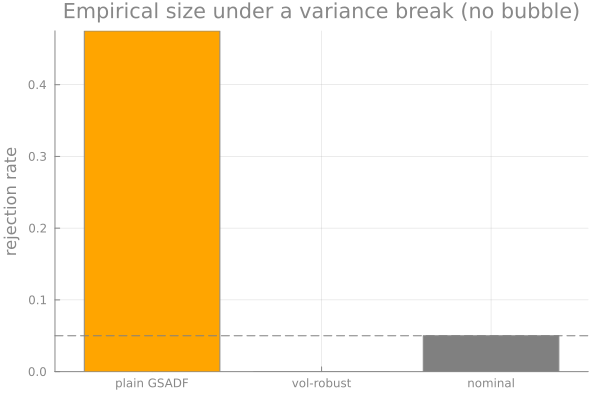

In [6]:
# WAVE29-BREAKS: empirical size, plain vs vol-robust vs nominal
bar(["plain GSADF", "vol-robust", "nominal"], [plain_size, vr_size, 0.05];
    legend = false, ylabel = "rejection rate",
    title = "Empirical size under a variance break (no bubble)",
    color = [:orange, :dodgerblue, :gray])
hline!([0.05]; ls = :dash, color = :gray)

In [7]:
# WAVE29-BREAKS: a genuine constant-volatility bubble is still detected (modest power cost)
function constant_vol_bubble(; n = 300, c = 1.06, lo = 100, hi = 160, seed = 3)
    rng = MersenneTwister(seed)
    y = zeros(n)
    for t in 2:n
        y[t] = (lo <= t < hi ? c * y[t-1] : y[t-1]) + randn(rng)
    end
    return y
end

vr_bubble = volatility_robust_sadf(constant_vol_bubble(); n_bootstrap = 199, random_state = 1)
println("Constant-volatility bubble (t = 100..160):  GSADF = ", round(vr_bubble.gsadf, digits = 2),
        "   p-value = ", round(vr_bubble.gsadf_pvalue, digits = 3),
        "   rejects? ", vr_bubble.reject_gsadf)

Constant-volatility bubble (t = 100..160):  GSADF = 35.99   p-value = 0.005   rejects? true


## 5. PELT: multiple and variance change-points CUSUM misses

<!-- WAVE29-BREAKS -->
de Prado's CUSUM test targets a **single mean shift** and is blind to a pure
**variance** change. **PELT** (Killick, Fearnhead and Eckley, 2012) finds the exact
set of **multiple** change-points minimizing a Gaussian (mean-and-variance) segment
cost plus a per-change penalty, dating multiple and variance breaks without
over-segmenting.

**Regime tag (verbatim, `appraisals/26_verdict.md`):** *prefer it over CUSUM for
detecting and dating multiple and/or variance change-points (which CUSUM misses),
without over-segmenting; CUSUM remains adequate for a single mean shift.*

In [8]:
# WAVE29-BREAKS: PELT on (a) three mean+variance change-points and (b) a pure variance shift
rng_m = MersenneTwister(2)
multi = vcat(randn(rng_m, 80), randn(rng_m, 80) .+ 4.0,
             2.5 .* randn(rng_m, 80) .+ 4.0, randn(rng_m, 80))
cps_multi = pelt_change_points(multi; penalty_multiplier = 2.0, min_size = 15, jump = 5)
println("Three true change-points at [80, 160, 240]; PELT detects: ", cps_multi)

rng_v = MersenneTwister(11)
var_only = vcat(randn(rng_v, 100), 3.0 .* randn(rng_v, 100))
cps_var = pelt_change_points(var_only)        # CUSUM is blind to this pure variance break
println("One true PURE-VARIANCE change-point at [100]; PELT detects: ", cps_var)

Three true change-points at [80, 160, 240]; PELT detects: [80, 150, 240]
One true PURE-VARIANCE change-point at [100]; PELT detects: [100]


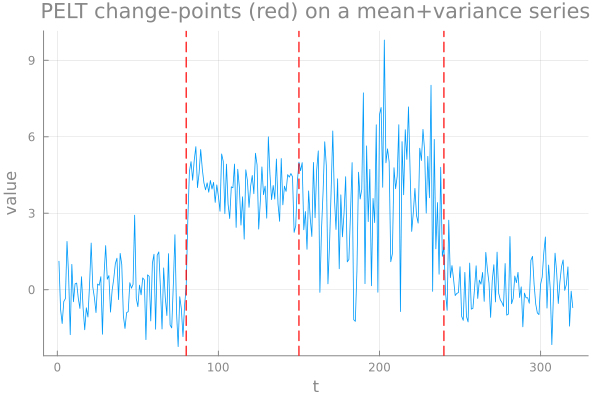

In [9]:
# WAVE29-BREAKS: visualize the PELT segmentation of the multi-break series
plot(multi; legend = false, lw = 0.8, xlabel = "t", ylabel = "value",
     title = "PELT change-points (red) on a mean+variance series")
vline!(cps_multi; color = :red, ls = :dash, lw = 1.2)

## When to use / when NOT (from `appraisals/05_verdict.md`)
**Prefer GSADF/BSADF over single-window SADF when a series may contain more than
one explosive episode** (it recovers and counts each). For a single suspected
bubble, SADF is at least as good. Use seasonally-adjusted data and the simulated
finite-sample critical values; **GSADF over-flags strongly trending or seasonal
series and is mildly oversized in large samples**, so treat broad flags
cautiously.

<!-- WAVE29-BREAKS-TAKE -->
**Volatility-robust SADF** (Appraisal 26): prefer it over plain SADF/GSADF when the
series' volatility may be non-stationary — the plain test over-rejects (empirical size
far above nominal here), while the wild-bootstrap calibration holds size and still
detects a genuine constant-volatility bubble.

**PELT** (Appraisal 26): prefer it over CUSUM to date multiple and/or variance
change-points (here three mean+variance breaks and a pure variance break), without
over-segmenting; CUSUM remains adequate for a single mean shift.